## Extended Data Fig. 5c

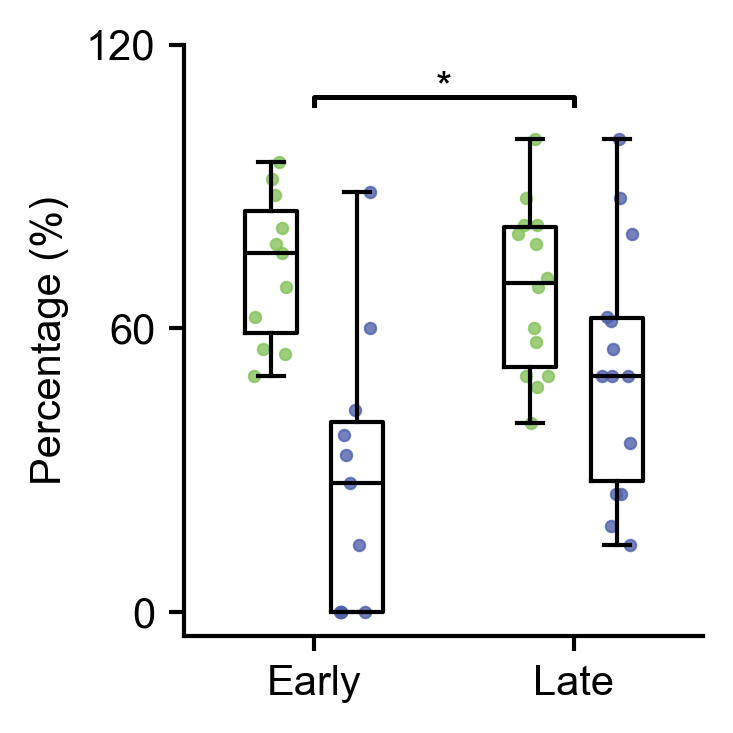

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../Results4Plots/percentage_dark.csv')
df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Stage"].isin(["early", "late"]))
    & (df["CellType"].isin(["PC", "GC"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]
cell_types = ["PC", "GC"]

colorPC = np.array([134, 194, 93]) / 255.0
colorGC = np.array([81, 98, 172]) / 255.0
cellColor = {"PC": colorPC, "GC": colorGC}

xpos = {
    ("early", "PC"): 1,
    ("early", "GC"): 2,
    ("late", "PC"): 4,
    ("late", "GC"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=300)

for st in stage_levels:
    for ct in cell_types:
        sub = df[(df["Stage"] == st) & (df["CellType"] == ct)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, ct)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width
        color = cellColor[ct]

        ax.scatter(
            x0 + jitter,
            y,
            s=7.5,
            marker="o",
            facecolors=color,
            edgecolors=color,
            linewidths=0.5,
            alpha=0.8,
            zorder=3
        )

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Percentage (%)", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

y = df["Value"].max() + gap + 5

ax.plot([1.5, 1.5, 4.5, 4.5], [y, y + h, y + h, y], lw=1.2, c="k")
ax.text(3, y + h + text_offset - 0.03 * yr, "*", ha="center", va="bottom", fontname="Arial", fontsize=10)

ax.set_ylim(-5, 120)
ax.set_yticks([0, 60, 120])
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()

## Extended Data Fig. 5d

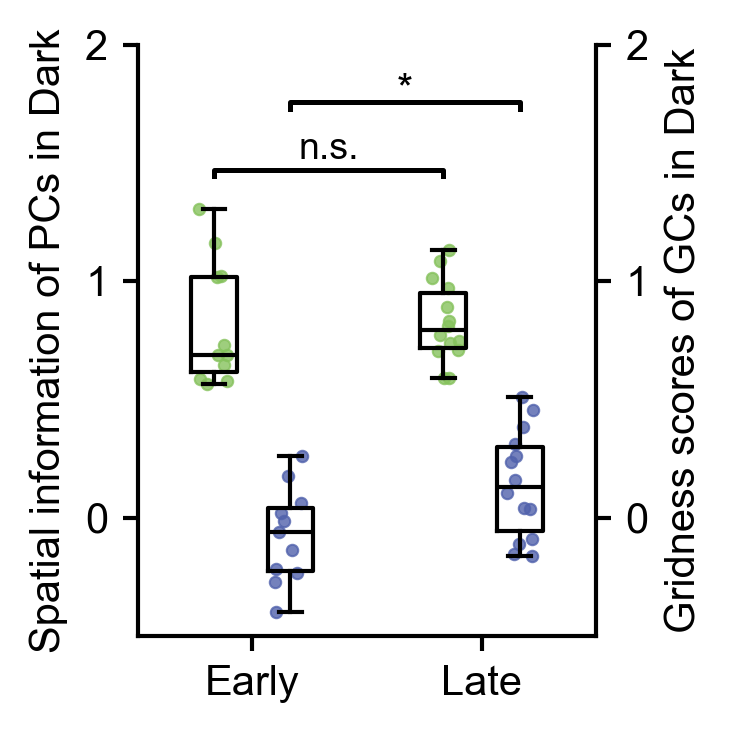

In [3]:
df = pd.read_csv('../Results4Plots/spatialinformation_gridnessscore_Dark.csv')
df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Stage"].isin(["early", "late"]))
    & (df["CellType"].isin(["PC", "GC"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]
cell_types = ["PC", "GC"]

colorPC = np.array([134, 194, 93]) / 255.0
colorGC = np.array([81, 98, 172]) / 255.0
cellColor = {"PC": colorPC, "GC": colorGC}

xpos = {
    ("early", "PC"): 1,
    ("early", "GC"): 2,
    ("late", "PC"): 4,
    ("late", "GC"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=300)

for st in stage_levels:
    for ct in cell_types:
        sub = df[(df["Stage"] == st) & (df["CellType"] == ct)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, ct)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width
        color = cellColor[ct]

        ax.scatter(
            x0 + jitter,
            y,
            s=7.5,
            marker="o",
            facecolors=color,
            edgecolors=color,
            linewidths=0.5,
            alpha=0.8,
            zorder=3
        )

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

base_top = df["Value"].max()
y_pc = base_top + gap + 0.1
y_gc = y_pc + h + 14 * text_offset + 0.02

ax.plot([1, 1, 4, 4], [y_pc, y_pc + h, y_pc + h, y_pc], lw=1.2, c="k")
ax.text(2.5, y_pc + h + text_offset, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.plot([2, 2, 5, 5], [y_gc, y_gc + h, y_gc + h, y_gc], lw=1.2, c="k")
ax.text(3.5, y_gc + h + text_offset - 0.05, "*", ha="center", va="bottom", fontname="Arial", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Spatial information of PCs in Dark", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(-0.5, 2)
ax.set_yticks([0, 1, 2])
ax.set_xlim(0, 6)

ax_r = ax.twinx()
ax_r.set_ylim(-0.5, 2)
ax_r.set_yticks([0, 1, 2])
ax_r.set_yticklabels(["0", "1", "2"], fontname="Arial", fontsize=10)
ax_r.set_ylabel("Gridness scores of GCs in Dark", fontsize=10, fontname="Arial")

ax_r.spines["top"].set_visible(False)
ax_r.spines["left"].set_visible(False)
ax_r.spines["bottom"].set_visible(False)
ax_r.spines["right"].set_linewidth(1)
ax_r.tick_params(axis="y", direction="out", length=3.5, width=1.0, labelsize=10)

plt.tight_layout(pad=0.2)
plt.show()

## Extended Data Fig. 5e

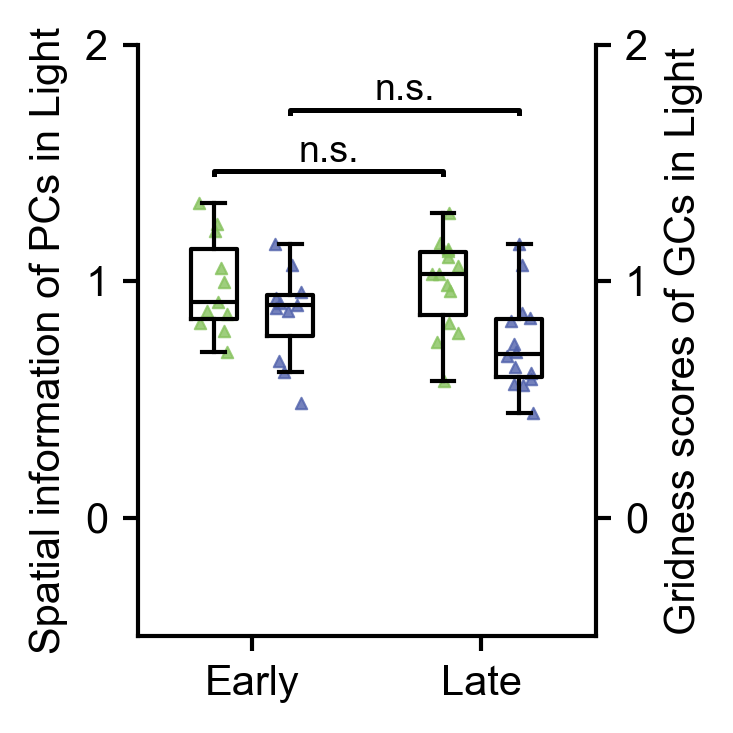

In [4]:
df = pd.read_csv('../Results4Plots/spatialinformation_gridnessscore_Light.csv')
df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Stage"].isin(["early", "late"]))
    & (df["CellType"].isin(["PC", "GC"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]
cell_types = ["PC", "GC"]

colorPC = np.array([134, 194, 93]) / 255.0
colorGC = np.array([81, 98, 172]) / 255.0
cellColor = {"PC": colorPC, "GC": colorGC}

xpos = {
    ("early", "PC"): 1,
    ("early", "GC"): 2,
    ("late", "PC"): 4,
    ("late", "GC"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=300)

for st in stage_levels:
    for ct in cell_types:
        sub = df[(df["Stage"] == st) & (df["CellType"] == ct)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, ct)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width
        color = cellColor[ct]

        ax.scatter(
            x0 + jitter,
            y,
            s=7.5,
            marker="^",
            facecolors=color,
            edgecolors=color,
            linewidths=0.5,
            alpha=0.8,
            zorder=3
        )

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

base_top = df["Value"].max()
y_pc = base_top + gap + 0.1
y_gc = y_pc + h + 14 * text_offset + 0.12

ax.plot([1, 1, 4, 4], [y_pc, y_pc + h, y_pc + h, y_pc], lw=1.2, c="k")
ax.text(2.5, y_pc + h + text_offset, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.plot([2, 2, 5, 5], [y_gc, y_gc + h, y_gc + h, y_gc], lw=1.2, c="k")
ax.text(3.5, y_gc + h + text_offset + 0.005, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Spatial information of PCs in Light", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(-0.5, 2)
ax.set_yticks([0, 1, 2])
ax.set_xlim(0, 6)

ax_r = ax.twinx()
ax_r.set_ylim(-0.5, 2)
ax_r.set_yticks([0, 1, 2])
ax_r.set_yticklabels(["0", "1", "2"], fontname="Arial", fontsize=10)
ax_r.set_ylabel("Gridness scores of GCs in Light", fontsize=10, fontname="Arial")

ax_r.spines["top"].set_visible(False)
ax_r.spines["left"].set_visible(False)
ax_r.spines["bottom"].set_visible(False)
ax_r.spines["right"].set_linewidth(1)

ax_r.tick_params(axis="y", direction="out", length=3.5, width=1.0, labelsize=10)

plt.tight_layout(pad=0.2)
plt.show()

## Extended Data Fig. 5f

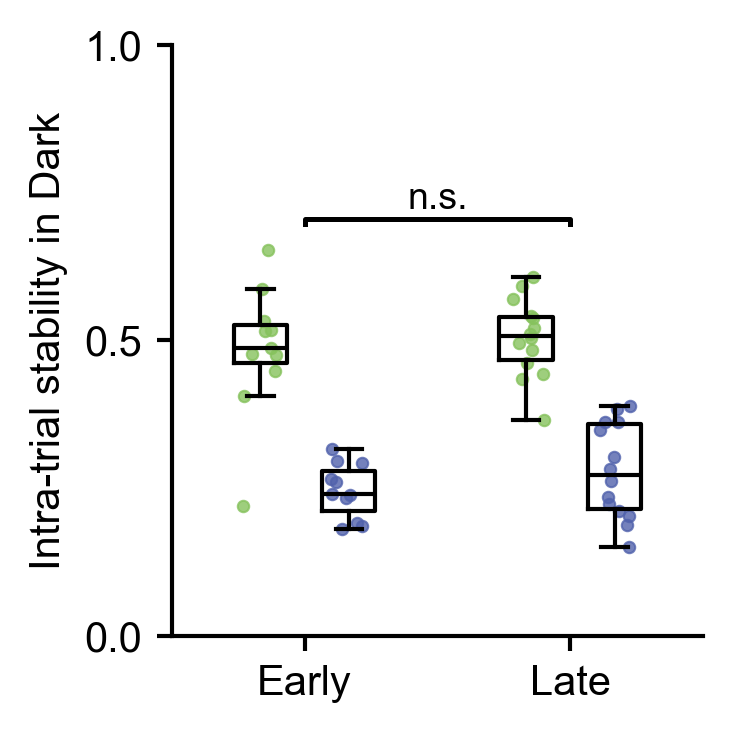

In [5]:
df = pd.read_csv('../Results4Plots/intratrial_stability_Dark.csv')
df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Stage"].isin(["early", "late"]))
    & (df["CellType"].isin(["PC", "GC"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]
cell_types = ["PC", "GC"]

colorPC = np.array([134, 194, 93]) / 255.0
colorGC = np.array([81, 98, 172]) / 255.0
cellColor = {"PC": colorPC, "GC": colorGC}

xpos = {
    ("early", "PC"): 1,
    ("early", "GC"): 2,
    ("late", "PC"): 4,
    ("late", "GC"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=300)

for st in stage_levels:
    for ct in cell_types:
        sub = df[(df["Stage"] == st) & (df["CellType"] == ct)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, ct)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width
        color = cellColor[ct]

        ax.scatter(
            x0 + jitter,
            y,
            s=7.5,
            marker="o",
            facecolors=color,
            edgecolors=color,
            linewidths=0.5,
            alpha=0.8,
            zorder=3
        )

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin

h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

y = df["Value"].max() + 4 * gap

ax.plot([1.5, 1.5, 4.5, 4.5], [y, y + h, y + h, y], lw=1.2, c="k")
ax.text(3, y + h + text_offset, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Intra-trial stability in Dark", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()

## Extended Data Fig. 5g

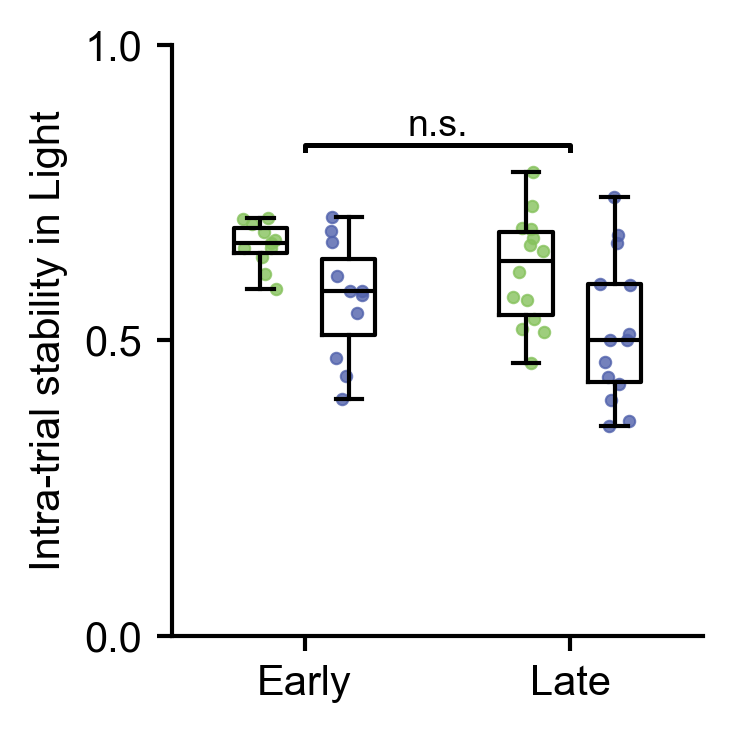

In [6]:
df = pd.read_csv('../Results4Plots/intratrial_stability_Light.csv')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Stage"].isin(["early", "late"]))
    & (df["CellType"].isin(["PC", "GC"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]
cell_types = ["PC", "GC"]

colorPC = np.array([134, 194, 93]) / 255.0
colorGC = np.array([81, 98, 172]) / 255.0
cellColor = {"PC": colorPC, "GC": colorGC}

xpos = {
    ("early", "PC"): 1,
    ("early", "GC"): 2,
    ("late", "PC"): 4,
    ("late", "GC"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=300)

for st in stage_levels:
    for ct in cell_types:
        sub = df[(df["Stage"] == st) & (df["CellType"] == ct)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, ct)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width
        color = cellColor[ct]

        ax.scatter(
            x0 + jitter,
            y,
            s=7.5,
            marker="o",
            facecolors=color,
            edgecolors=color,
            linewidths=0.5,
            alpha=0.8,
            zorder=3
        )

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin

h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

y = df["Value"].max() + 4 * gap

ax.plot([1.5, 1.5, 4.5, 4.5], [y, y + h, y + h, y], lw=1.2, c="k")
ax.text(3, y + h + text_offset, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Intra-trial stability in Light", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()